# Data Analysis for Option 1 Results

In [131]:
import pandas as pd
import numpy 
import os

endpoint = "sub-liver"
increment = 5

full_df = pd.read_csv(f"../references/full_print_results/{endpoint}/big_results_percentages{increment}.csv")
full_df = full_df.drop(columns = {"Unnamed: 0"})

if not os.path.exists(f"..references/full_print_results/{endpoint}/full_scatters"):
    for folder in ["full_scatters", "Highlights", "multi-scores", "reg1_graphs", "reg2_graphs", "reg3_graphs", "strat_graphs"]:
        os.mkdir(f"../references/full_print_results/{endpoint}/{folder}")

In [132]:
full_df[['param_hybrid_weights','split0_test_accuracy',
       'split1_test_accuracy', 'split2_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy']].head(10)

,param_hybrid_weights,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,mean_test_accuracy,std_test_accuracy
0,"[0, 0, 0, 0, 100]",0.766667,0.700000,0.777778,0.753333,0.027577
1,"[0, 0, 0, 5, 95]",0.766667,0.700000,0.766667,0.751111,0.025915
2,"[0, 0, 0, 10, 90]",0.766667,0.688889,0.766667,0.748889,0.030307
3,"[0, 0, 0, 15, 85]",0.766667,0.711111,0.766667,0.753333,0.021545
4,"[0, 0, 0, 20, 80]",0.766667,0.711111,0.744444,0.748889,0.020608
5,"[0, 0, 0, 25, 75]",0.766667,0.711111,0.744444,0.748889,0.020608
6,"[0, 0, 0, 30, 70]",0.766667,0.711111,0.744444,0.746667,0.020367
7,"[0, 0, 0, 35, 65]",0.766667,0.711111,0.744444,0.746667,0.020367
8,"[0, 0, 0, 40, 60]",0.766667,0.733333,0.744444,0.751111,0.013333
9,"[0, 0, 0, 45, 55]",0.755556,0.722222,0.744444,0.746667,0.014741


In [83]:
#Weights saved as a string for the CSV, so we will fix this (if integer weights)
# df = full_df[["param_hybrid_weights", "mean_test_accuracy","mean_test_precision","mean_test_recall", "mean_test_roc_auc"]].sort_values("mean_test_roc_auc", ascending = False) 
# df["param_hybrid_weights"] = [ [int(df["param_hybrid_weights"][i][1]), int(df["param_hybrid_weights"][i][4]), int(df["param_hybrid_weights"][i][7]), int(df["param_hybrid_weights"][i][10]), int(df["param_hybrid_weights"][i][13])] for i in range(0, len(df["param_hybrid_weights"]))]
# df.head()

In [133]:
#If percentage weights, we will need this version:
df = full_df[["param_hybrid_weights", "mean_test_accuracy","mean_test_precision","mean_test_recall", "mean_test_roc_auc"]].sort_values("mean_test_roc_auc", ascending = False) 
new_weights = []
for i in df["param_hybrid_weights"]:
    number_list = i.split(",")
    first = number_list[0][1:]
    last = number_list[-1][:-1]
    new_weights.append([int(first), int(number_list[1]), int(number_list[2]), int(number_list[3]), int(last)])
df["param_hybrid_weights"] = new_weights

In [134]:
#Calculate percentage contributions from the weights, as these are often more intuitive
morgan_weight = [df["param_hybrid_weights"][i][1] for i in range(0,len(df["param_hybrid_weights"]))]
toxprint_weight = [df["param_hybrid_weights"][i][0] for i in range(0,len(df["param_hybrid_weights"]))]
torsion_weight = [df["param_hybrid_weights"][i][2] for i in range(0,len(df["param_hybrid_weights"]))]
toxcast_weight = [df["param_hybrid_weights"][i][3] for i in range(0,len(df["param_hybrid_weights"]))]
aims_weight = [df["param_hybrid_weights"][i][4] for i in range(0,len(df["param_hybrid_weights"]))]

df["morgan"] = [morgan_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(morgan_weight))]
df["toxprint"] = [toxprint_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(toxprint_weight))]
df["torsion"] = [torsion_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(torsion_weight))]
df["toxcast"] = [toxcast_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(toxcast_weight))]
df["aims"] = [aims_weight[i]/sum(df["param_hybrid_weights"][i]) for i in range(0,len(aims_weight))]


In [114]:
df = df.sort_values("mean_test_accuracy", ascending = False).drop(columns = {"param_hybrid_weights"})
df.head()

,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
583,0.634783,0.643150,0.774333,0.620200,0.50,0.05,0.30,0.15,0.00
87,0.630435,0.633310,0.807000,0.639988,0.15,0.00,0.60,0.10,0.15
2191,0.630435,0.643044,0.791000,0.658345,0.00,0.00,0.05,0.95,0.00
2123,0.630435,0.632048,0.782333,0.606103,0.05,0.20,0.20,0.25,0.30
631,0.630435,0.645673,0.783667,0.630018,0.00,0.05,0.15,0.05,0.75


## Top/Bottom DataFrame Creation
 There are many, many results for this data set, so let's look only at the best and worst in each category to examine patterns as well. 

In [135]:
accuracy_df1 = df.sort_values("mean_test_accuracy").iloc[0:10, :]
accuracy_df2 = df.sort_values("mean_test_accuracy").iloc[-10:, :]
accuracy_df3 = df.sort_values("mean_test_accuracy").iloc[round(len(df)/2-5):round(len(df)/2+5), :]
accuracy_df = pd.concat([accuracy_df1, accuracy_df2, accuracy_df3]).sort_values("mean_test_accuracy", ascending = False)
accuracy_df.head(10)

,param_hybrid_weights,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
1428,"[0, 45, 5, 45, 5]",0.766667,0.768592,0.994160,0.583249,0.25,0.30,0.05,0.40,0.00
648,"[0, 15, 0, 85, 0]",0.766667,0.766167,1.000000,0.548347,0.00,0.75,0.05,0.10,0.10
39,"[0, 0, 5, 90, 5]",0.766667,0.766167,1.000000,0.544806,0.20,0.75,0.05,0.00,0.00
1494,"[0, 50, 0, 45, 5]",0.766667,0.768592,0.994160,0.582304,0.40,0.30,0.10,0.20,0.00
2659,"[5, 25, 5, 65, 0]",0.766667,0.767405,0.997101,0.576944,0.00,0.40,0.15,0.30,0.15
1103,"[0, 30, 0, 60, 10]",0.766667,0.767405,0.997101,0.579695,0.10,0.35,0.45,0.05,0.05
970,"[0, 25, 0, 75, 0]",0.766667,0.767366,0.997101,0.564663,0.00,0.55,0.20,0.20,0.05
3704,"[10, 10, 5, 75, 0]",0.766667,0.768617,0.994203,0.563034,0.10,0.55,0.10,0.25,0.00
3346,"[10, 0, 5, 80, 5]",0.766667,0.767366,0.997101,0.569375,0.40,0.45,0.05,0.10,0.00
1999,"[5, 5, 0, 90, 0]",0.764444,0.764444,1.000000,0.549195,0.20,0.70,0.00,0.10,0.00


In [136]:
precision_df1 = df.sort_values("mean_test_precision").iloc[0:10, :]
precision_df2 = df.sort_values("mean_test_precision").iloc[-10:, :]
precision_df3 = df.sort_values("mean_test_precision").iloc[round(len(df)/2-5):round(len(df)/2+5), :]
precision_df = pd.concat([precision_df1, precision_df2, precision_df3]).sort_values("mean_test_precision", ascending = False)
precision_df.head(10)

,param_hybrid_weights,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
5736,"[15, 60, 10, 0, 15]",0.757778,0.770260,0.973913,0.618581,0.05,0.05,0.55,0.35,0.00
5687,"[15, 50, 20, 0, 15]",0.757778,0.770260,0.973913,0.627962,0.25,0.00,0.45,0.20,0.10
5715,"[15, 55, 15, 0, 15]",0.755556,0.769749,0.971014,0.622422,0.65,0.00,0.20,0.05,0.10
4534,"[10, 55, 5, 25, 5]",0.760000,0.769490,0.979668,0.600226,0.20,0.15,0.20,0.45,0.00
4590,"[10, 65, 0, 25, 0]",0.760000,0.769490,0.979668,0.608193,0.10,0.10,0.70,0.00,0.10
5750,"[15, 65, 0, 20, 0]",0.760000,0.769481,0.979710,0.609393,0.05,0.10,0.35,0.10,0.40
4536,"[10, 55, 10, 0, 25]",0.757778,0.769125,0.976812,0.624037,0.50,0.00,0.05,0.30,0.15
4610,"[10, 70, 0, 20, 0]",0.757778,0.768973,0.976812,0.616806,0.15,0.05,0.20,0.45,0.15
4595,"[10, 65, 5, 20, 0]",0.757778,0.768973,0.976812,0.600922,0.15,0.15,0.15,0.15,0.40
5708,"[15, 55, 5, 20, 5]",0.757778,0.768932,0.976769,0.612465,0.50,0.05,0.00,0.45,0.00


In [137]:
recall_df1 = df.sort_values("mean_test_recall").iloc[0:10, :]
recall_df2 = df.sort_values("mean_test_recall").iloc[-10:, :]
recall_df3 = df.sort_values("mean_test_recall").iloc[round(len(df)/2-5):round(len(df)/2+5), :]
recall_df = pd.concat([recall_df1, recall_df2, recall_df3]).sort_values("mean_test_recall", ascending = False)
recall_df.head(10)

,param_hybrid_weights,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
250,"[0, 5, 0, 95, 0]",0.764444,0.764444,1.000000,0.532031,0.05,0.90,0.05,0.00,0.00
20,"[0, 0, 0, 100, 0]",0.764444,0.764444,1.000000,0.516457,0.00,1.00,0.00,0.00,0.00
459,"[0, 10, 0, 90, 0]",0.764444,0.764444,1.000000,0.519557,0.05,0.95,0.00,0.00,0.00
39,"[0, 0, 5, 90, 5]",0.766667,0.766167,1.000000,0.544806,0.20,0.75,0.05,0.00,0.00
1790,"[5, 0, 0, 95, 0]",0.764444,0.764444,1.000000,0.540182,0.20,0.80,0.00,0.00,0.00
19,"[0, 0, 0, 95, 5]",0.764444,0.764444,1.000000,0.534440,0.00,0.90,0.05,0.00,0.05
648,"[0, 15, 0, 85, 0]",0.766667,0.766167,1.000000,0.548347,0.00,0.75,0.05,0.10,0.10
1999,"[5, 5, 0, 90, 0]",0.764444,0.764444,1.000000,0.549195,0.20,0.70,0.00,0.10,0.00
2188,"[5, 10, 0, 85, 0]",0.764444,0.765643,0.997101,0.551483,0.05,0.70,0.10,0.10,0.05
1808,"[5, 0, 5, 85, 5]",0.762222,0.763920,0.997101,0.547825,0.00,0.75,0.10,0.15,0.00


In [138]:
roc_df1 = df.sort_values("mean_test_roc_auc").iloc[0:10, :]
roc_df2 = df.sort_values("mean_test_roc_auc").iloc[-10:, :]
roc_df3 = df.sort_values("mean_test_roc_auc").iloc[round(len(df)/2-5):round(len(df)/2+5), :]
roc_df = pd.concat([roc_df1, roc_df2, roc_df3]).sort_values("mean_test_roc_auc", ascending=False)
roc_df.head(10)

,param_hybrid_weights,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_roc_auc,morgan,toxprint,torsion,toxcast,aims
8006,"[30, 20, 25, 5, 20]",0.740000,0.761910,0.959420,0.663744,0.0,0.0,0.0,0.00,1.00
7468,"[25, 40, 15, 5, 15]",0.751111,0.764603,0.973913,0.660499,0.0,0.0,0.0,0.05,0.95
7420,"[25, 35, 10, 10, 20]",0.751111,0.762232,0.979710,0.659204,0.0,0.0,0.0,0.10,0.90
6559,"[20, 35, 15, 10, 20]",0.755556,0.766918,0.976812,0.658422,0.0,0.0,0.0,0.15,0.85
8112,"[30, 30, 20, 5, 15]",0.751111,0.765928,0.971014,0.657799,0.0,0.0,0.0,0.20,0.80
6496,"[20, 30, 15, 10, 25]",0.748889,0.762827,0.973913,0.657079,0.0,0.0,0.0,0.25,0.75
8100,"[30, 30, 10, 10, 20]",0.748889,0.762827,0.973913,0.656493,0.0,0.0,0.0,0.30,0.70
7933,"[30, 15, 25, 5, 25]",0.744444,0.761684,0.968116,0.655895,0.0,0.0,0.0,0.35,0.65
6604,"[20, 40, 10, 10, 20]",0.751111,0.763444,0.976812,0.655752,0.0,0.0,0.0,0.40,0.60
5527,"[15, 35, 15, 10, 25]",0.751111,0.764603,0.973913,0.655216,0.0,0.0,0.0,0.45,0.55


## Graph Generation

In [139]:
#Master test variable settings, for generating graphs with given settings from all cells
test_variables = {"x":"aims", "y":"accuracy", "c":"toxcast"}

### Stratified Graphs

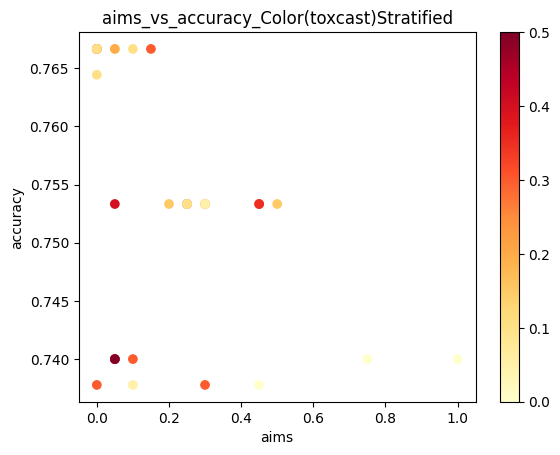

In [142]:
import matplotlib.pyplot as plt

#View and save results as scatterplot to analyze for trends. Note that most relations do not 
# appear to be linear, so such a regression may not be the best choice

#Accuracy strata
test_variables["y"] = "accuracy"
plt.scatter(x = accuracy_df[test_variables["x"]], y= accuracy_df["mean_test_accuracy"], c= accuracy_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

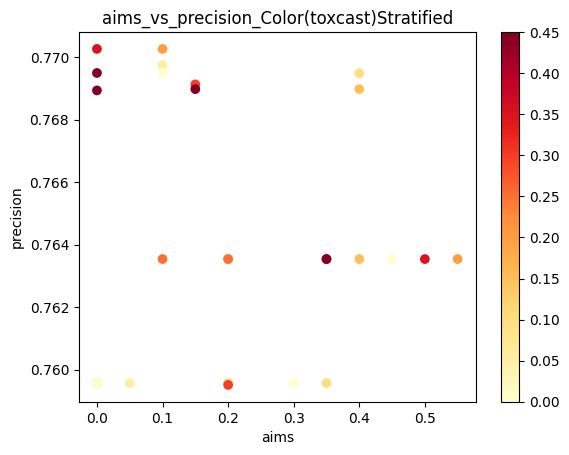

In [143]:
#Precision strata
test_variables["y"] = "precision"
plt.scatter(x = precision_df[test_variables["x"]], y= precision_df["mean_test_precision"], c= precision_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

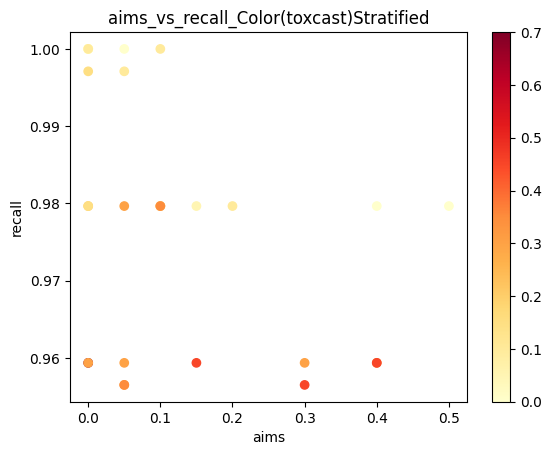

In [144]:
#Recall strata
test_variables["y"] = "recall"
plt.scatter(x = recall_df[test_variables["x"]], y= recall_df["mean_test_recall"], c= recall_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

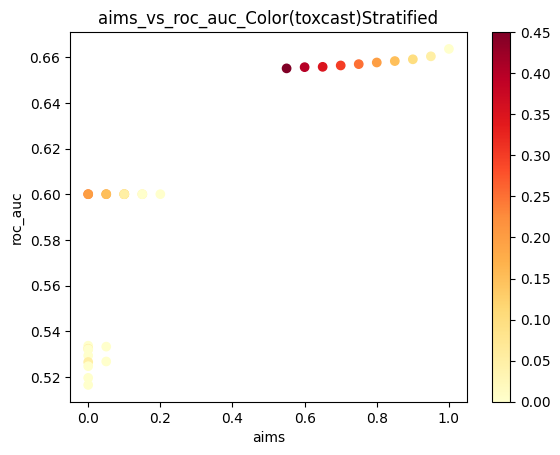

In [145]:
#ROC strata
test_variables["y"] = "roc_auc"
plt.scatter(x = roc_df[test_variables["x"]], y= roc_df["mean_test_roc_auc"], c= roc_df[test_variables["c"]], cmap = "YlOrRd")
plt.colorbar()
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color({test_variables["c"]})Stratified"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/strat_graphs/{title}_scatter.png")
plt.show()

### Full data graph

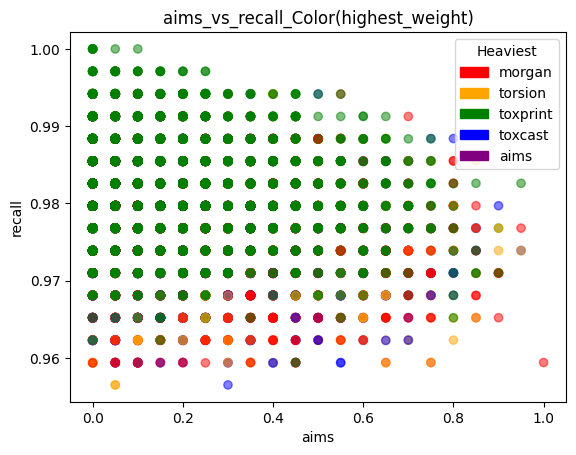

In [150]:
#Full data set comparisons
import matplotlib.patches as mpatches

df = df.reset_index(drop=True)
test_variables["y"] = "recall"

color_map = {"morgan":"red", "torsion":"orange", "toxprint":"green", "toxcast":"blue", "aims":"purple"}
color_list = []
for i in range(0,len(df)):
    measures = {"morgan":df["morgan"][i], "torsion":df["torsion"][i], "toxprint":df["toxprint"][i], "toxcast":df["toxcast"][i], "aims":df["aims"][i]}
    measures.pop(test_variables['x'])
    max_spot = list(measures.values()).index(max(measures.values()))
    color_list.append(color_map[list(measures.keys())[max_spot]])

plt.scatter(x = df[test_variables["x"]], y= df[f"mean_test_{test_variables["y"]}"], c= color_list, alpha=0.5)
plt.xlabel(test_variables["x"])
plt.ylabel(test_variables["y"])
legend = [mpatches.Patch(color = value, label = key) for key, value in color_map.items()]
title = f"{test_variables["x"]}_vs_{test_variables["y"]}_Color(highest_weight)"
plt.title(title)
plt.legend(title = "Heaviest", handles = legend)
plt.savefig(f"../references/full_print_results/{endpoint}/full_scatters/{title}_scatter.png")
plt.show()

### Regression-Ready Graphs 
These first two were visually informative when we worked with the four_print_results, but became overloaded in some areas and underloaded in others when the many extra tests of the full results were introduced. A reworked attempt can be seen below. 

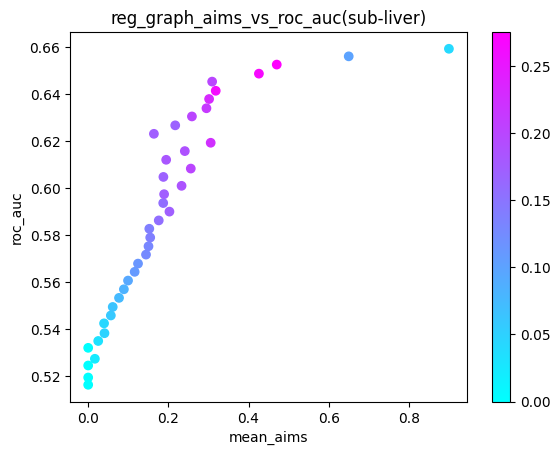

In [147]:
from numpy import arange
from statistics import mean

#Plot average weight of a given fingerprint against the average score in a given neighborhood, this could
#allow for regression analysis of the relation between fingerprint weight and scores
score = "roc_auc"
weight = test_variables["x"]

averages = {score:[], weight: [], "size":[], "std": [] }
minimum = min(df[f"mean_test_{score}"])
maximum = max(df[f"mean_test_{score}"])
data_range = maximum -minimum

for i in arange(minimum, maximum, data_range/40):
    selection = df.loc[(df[f"mean_test_{score}"] < i+data_range/80) & (df[f"mean_test_{score}"] >= i-data_range/80)]
    selection_weight = selection[weight]
    selection_score = selection[f"mean_test_{score}"]
    if len(selection) > 0:
        avg_weight = mean(selection_weight)
        avg_score = mean(selection_score)
        averages[score].append(avg_score)
        averages[weight].append(avg_weight)
        averages["size"].append(len(selection))
        averages["std"].append(numpy.std(selection_weight))

avg_df = pd.DataFrame(averages)

#Color bar will show how many data points from the main data frame contribute to each plotted point 
#to demonstrate some estimate of confidence
plt.scatter(x = avg_df[weight], y = avg_df[score], c = avg_df["std"], cmap = "cool", )
plt.colorbar()
plt.xlabel("mean_"+weight)
plt.ylabel(score)
title = f"reg_graph_{weight}_vs_{score}({endpoint})"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/reg1_graphs/{title}.png")
plt.show()

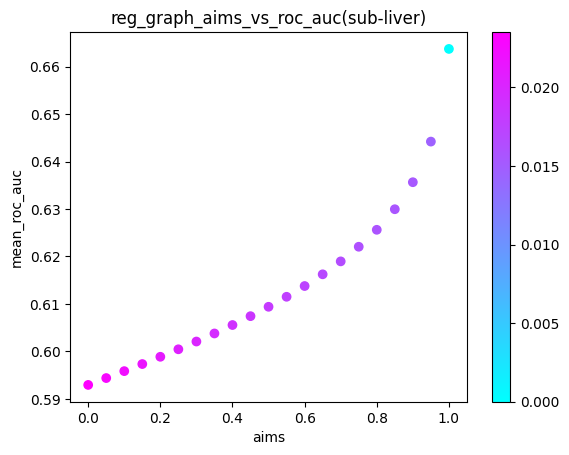

In [148]:
#For each possible weight of a fingerprint, plot average performance by score
score = "roc_auc"
weight = test_variables["x"]

averages = {score:[], weight: [], "size":[], "std":[] }

#For int weights: arange step = 0.03. For percent weights: arange step = 0.1

for i in arange(0,1.1, 0.05):
    selection = df.loc[(df[weight] < i+0.025) & (df[weight] >= i-0.025)]
    selection_weight = selection[weight]
    selection_score = selection[f"mean_test_{score}"]
    if len(selection) > 0:
        avg_weight = mean(selection_weight)
        avg_score = mean(selection_score)
        averages[score].append(avg_score)
        averages[weight].append(avg_weight)
        averages["size"].append(len(selection))
        averages["std"].append(numpy.std(selection_score))

avg_df = pd.DataFrame(averages)

#Color bar will show how many data points from the main data frame contribute to each plotted point 
#to demonstrate some estimate of confidence
plt.scatter(x = avg_df[weight], y = avg_df[score], c = avg_df["std"], cmap = "cool",)
plt.colorbar()
plt.xlabel(weight)
plt.ylabel("mean_"+score)
title = f"reg_graph_{weight}_vs_{score}({endpoint})"
plt.title(title)
plt.savefig(f"../references/full_print_results/{endpoint}/reg2_graphs/{title}.png")
plt.show()

#### Reworked Reg_graphs (int weights only)

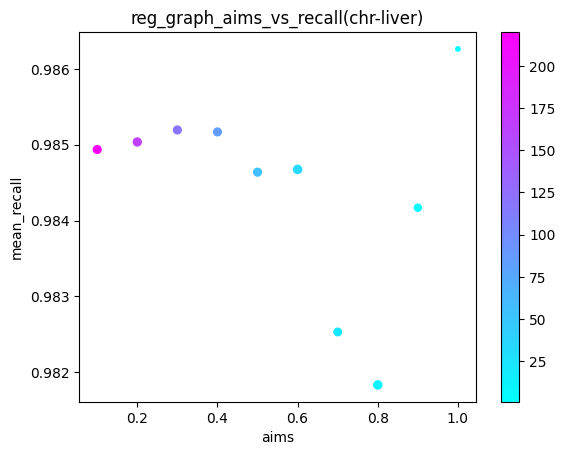

In [1008]:
#For each possible weight of a fingerprint, plot average performance by score
import numpy
from numpy import exp
score = "recall"
weight = test_variables["x"]

averages = {score:[], weight: [], "std": [], "size":[]}

next_start = 0
for i in arange(0,1, 0.01):
    selection = df.loc[(df[weight]>next_start) & (df[weight]< (next_start + exp(-10)*exp(10*i)))]
    next_start = (next_start + exp(-10)*exp(10*i))
    selection_weight = selection[weight]
    selection_score = selection[f"mean_test_{score}"]
    if len(selection) > 0:
        avg_weight = mean(selection_weight)
        avg_score = mean(selection_score)
        averages[score].append(avg_score)
        averages[weight].append(avg_weight)
        averages["std"].append(numpy.std(selection_score))
        averages["size"].append(len(selection))

avg_df = pd.DataFrame(averages)

#Color bar will show how many data points from the main data frame contribute to each plotted point 
#to demonstrate some estimate of confidence
plt.scatter(x = avg_df[weight], y = avg_df[score], c = avg_df["size"], cmap = "cool", s = 5000*avg_df["std"]+10)
plt.colorbar()
plt.xlabel(weight)
plt.ylabel("mean_"+score)
title = f"reg_graph_{weight}_vs_{score}({endpoint})"
plt.title(title)
# plt.savefig(f"../references/full_print_results/{endpoint}/reg3_graphs/{title}.png")
plt.show()

### Full Scatter Graph

c:\Users\aleary\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


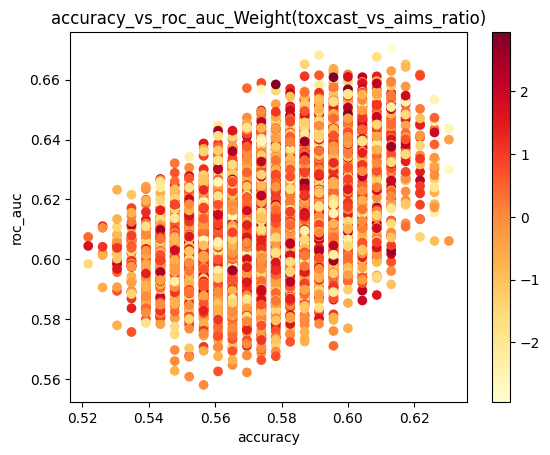

In [129]:
#Multi-scores
multi_variables = {"x":"accuracy", "y":"roc_auc", "c":"toxprint"}
plt.scatter(x = df[f"mean_test_{multi_variables["x"]}"], y=df[f"mean_test_{multi_variables["y"]}"], c= numpy.log(df["toxcast"]/df["aims"]), cmap = "YlOrRd")
plt.colorbar()
title = f"{multi_variables["x"]}_vs_{multi_variables["y"]}_Weight(toxcast_vs_aims_ratio)"
plt.title(title)
plt.xlabel(multi_variables["x"])
plt.ylabel(multi_variables["y"])
plt.savefig(f"../references/full_print_results/{endpoint}/multi-scores/{title}_scatter.png")
plt.show()

# Data Analysis for Long-Form Results

In [17]:
import pandas as pd

score_df = pd.read_csv("../references/tp_tor_mor/prelim_results+tc_df.csv")
score_df["weights"] = [ [int(score_df["weights"][i][1]), int(score_df["weights"][i][4]), int(score_df["weights"][i][7]), int(score_df["weights"][i][10])] for i in range(0, len(score_df["weights"]))]
score_df.head()

,weights,TP,TN,FP,FN,accuracy,precision,recall
0,"[0, 0, 0, 1]",336,18,88,26,0.756410,0.792453,0.928177
1,"[0, 0, 1, 0]",331,17,89,31,0.743590,0.788095,0.914365
2,"[0, 0, 1, 1]",336,13,93,26,0.745726,0.783217,0.928177
3,"[0, 0, 1, 2]",339,12,94,23,0.750000,0.782910,0.936464
4,"[0, 0, 2, 1]",335,14,92,27,0.745726,0.784543,0.925414


In [32]:
#Calculate percentage contributions from the weights, as these are often more intuitive
morgan_weight = [score_df["weights"][i][1] for i in range(0,len(score_df["weights"]))]
toxprint_weight = [score_df["weights"][i][0] for i in range(0,len(score_df["weights"]))]
torsion_weight = [score_df["weights"][i][2] for i in range(0,len(score_df["weights"]))]
toxcast_weight = [score_df["weights"][i][3] for i in range(0,len(score_df["weights"]))]

score_df["morgan"] = [morgan_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(morgan_weight))]
score_df["toxprint"] = [toxprint_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(toxprint_weight))]
score_df["torsion"] = [torsion_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(torsion_weight))]
score_df["toxcast"] = [toxcast_weight[i]/sum(score_df["weights"][i]) for i in range(0,len(toxcast_weight))]

In [33]:
#Check the DataFrame
score_df.head()

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
0,"[0, 0, 0, 1]",336,18,88,26,0.756410,0.792453,0.928177,0.0,0.0,0.000000,1.000000
1,"[0, 0, 1, 0]",331,17,89,31,0.743590,0.788095,0.914365,0.0,0.0,1.000000,0.000000
2,"[0, 0, 1, 1]",336,13,93,26,0.745726,0.783217,0.928177,0.0,0.0,0.500000,0.500000
3,"[0, 0, 1, 2]",339,12,94,23,0.750000,0.782910,0.936464,0.0,0.0,0.333333,0.666667
4,"[0, 0, 2, 1]",335,14,92,27,0.745726,0.784543,0.925414,0.0,0.0,0.666667,0.333333


In [34]:
#Obtain best combination for accuracy
score_df.loc[score_df["accuracy"]==max(score_df["accuracy"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
22,"[1, 0, 1, 0]",344,16,90,18,0.769231,0.792627,0.950276,0.0,0.5,0.5,0.0


In [35]:
#Obtain best combination for precision
score_df.loc[score_df["precision"]==max(score_df["precision"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
50,"[2, 0, 2, 1]",341,17,89,21,0.764957,0.793023,0.941989,0.0,0.4,0.4,0.2


In [36]:
#Obtain best combination for recall
score_df.loc[score_df["recall"]==max(score_df["recall"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
19,"[1, 0, 0, 0]",345,11,95,17,0.760684,0.784091,0.953039,0.0,1.0,0.0,0.0


In [37]:
#Obtain best combination for not getting false positives
score_df.loc[score_df["FP"]==min(score_df["FP"])]

,weights,TP,TN,FP,FN,accuracy,precision,recall,morgan,toxprint,torsion,toxcast
0,"[0, 0, 0, 1]",336,18,88,26,0.75641,0.792453,0.928177,0.0,0.0,0.0,1.0
27,"[1, 0, 2, 2]",336,18,88,26,0.75641,0.792453,0.928177,0.0,0.2,0.4,0.4


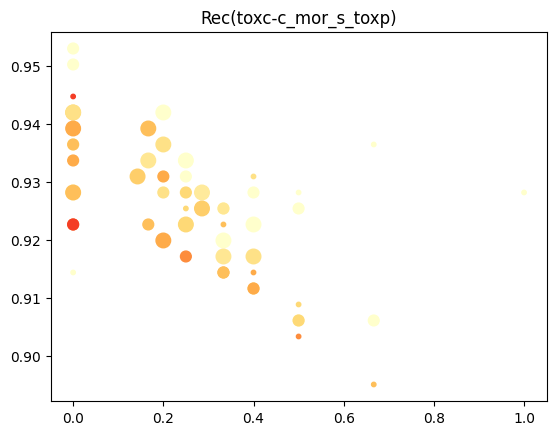

In [38]:
import matplotlib.pyplot as plt

#View and save results as scatterplot to analyze for trends. Note that most relations do not 
# appear to be linear, so such a regression may not be the best choice
plt.scatter(x = score_df["toxcast"], y= score_df["recall"], c= score_df["morgan"], cmap = "YlOrRd", s = [i*50+10 for i in toxprint_weight])
title = "Rec(toxc-c_mor_s_toxp)"
plt.title(title)
# plt.savefig(f"../references/tp_tor_mor/91test{title}percents_scatter.png")
plt.show()